In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
print("TensorFlow Version:", tf.version)

TensorFlow Version: <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>


In [61]:
df = pd.read_csv("TSLA.csv")

print(df.head())

         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900


In [63]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape:
(2416, 7)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB
None

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Statistical Summary:
              Open         High          Low        Close    Adj Close  \
count  2416.000000  2416.000000  2416.000000  2416.000000  2416.000000   
mean    186.271147   189.578224   182.916639   186.403651   186.403651   
std     118.740163   120.892329   116.857591 

In [64]:
df['Date'] = pd.to_datetime(df['Date'])

In [65]:
df.set_index('Date', inplace=True)

df.sort_index(inplace=True)

In [ ]:
df['column'] = df['column'].ffill()

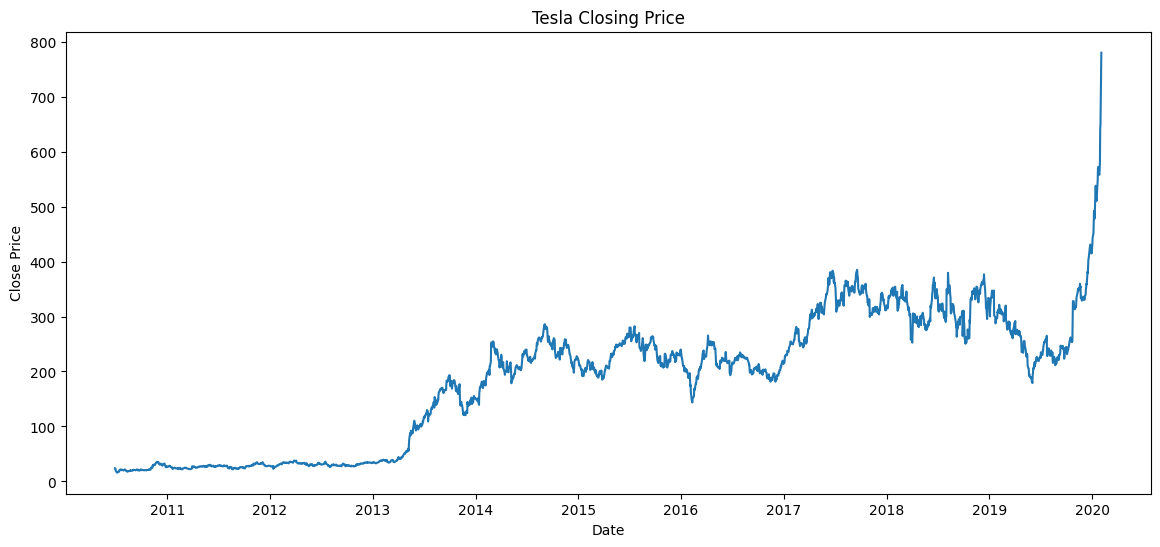

In [67]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'])
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

### Insight
- Observe the overall Tesla closing-price trend, major rallies, and sharp declines.
- Check whether the stock exhibits long-term growth and periods of high volatility.

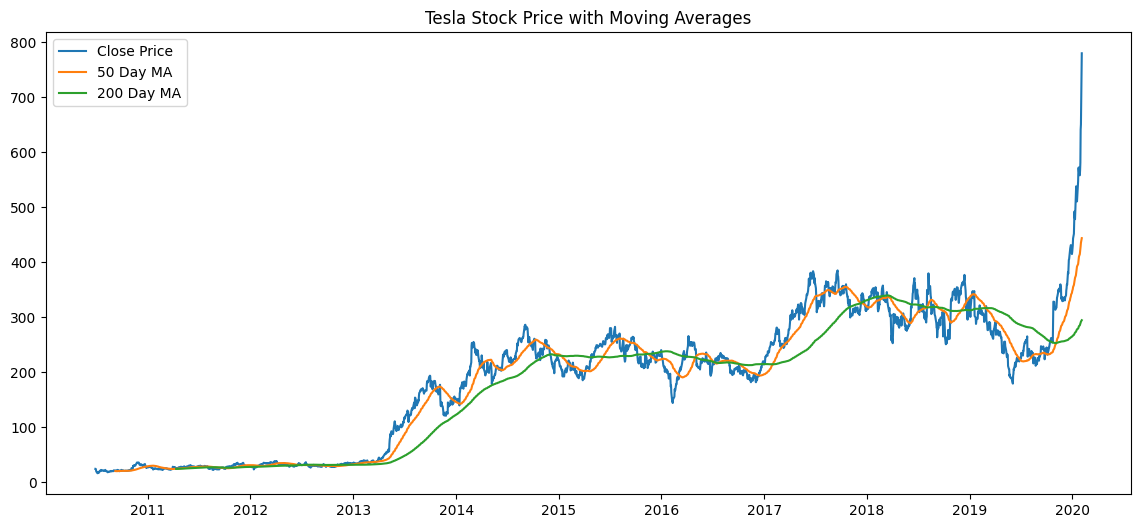

In [68]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_50'], label='50 Day MA')
plt.plot(df['MA_200'], label='200 Day MA')
plt.legend()
plt.title("Tesla Stock Price with Moving Averages")
plt.show()

### Insight
- When the 50-day moving average crosses above the 200-day moving average, it may indicate a bullish trend (Golden Cross).
- A cross below may indicate a bearish trend (Death Cross).

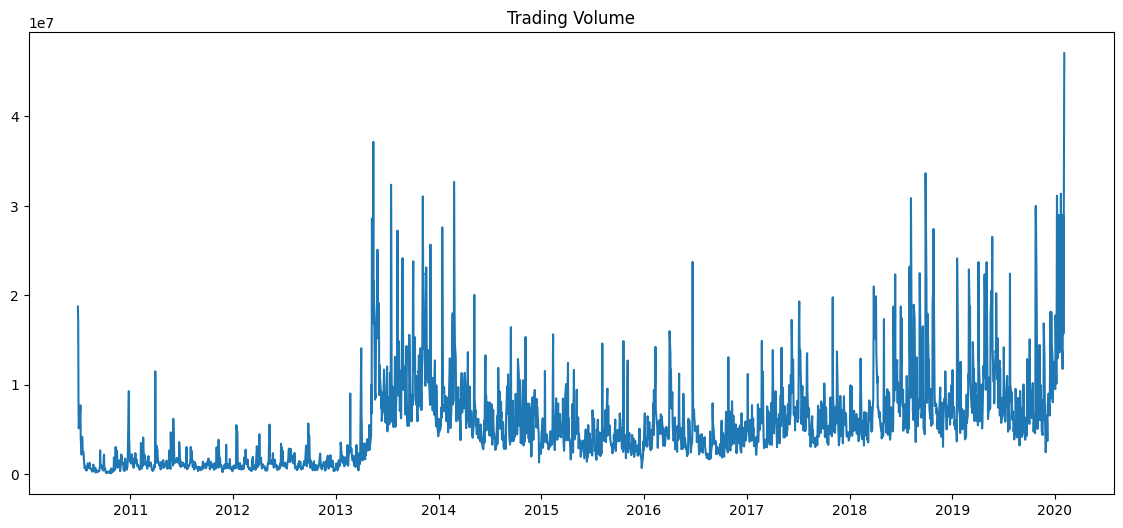

In [69]:
plt.figure(figsize=(14,6))
plt.plot(df['Volume'])
plt.title("Trading Volume")
plt.show()

### Insight
- Volume spikes often correspond to important news, earnings releases, or strong market sentiment.
- Compare volume spikes with price movements for deeper analysis.

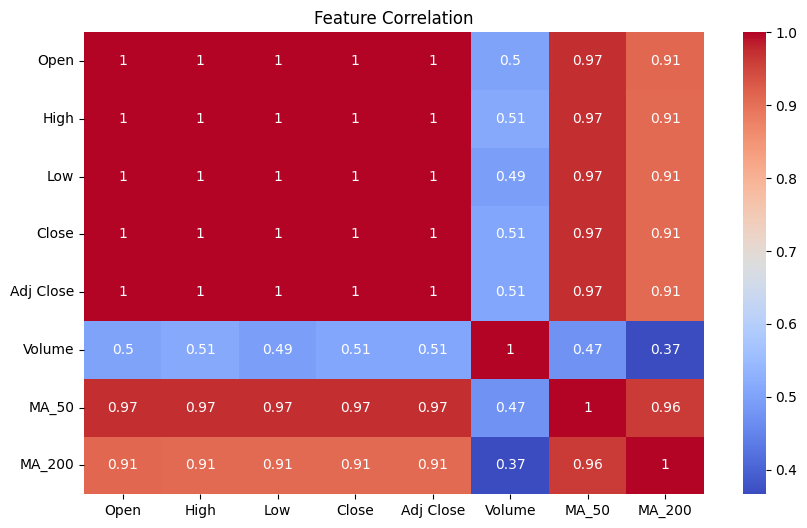

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Insight
- Strong positive correlations indicate features moving together.
- High correlation between OHLC prices is expected in stock-market data.

In [71]:
data = df[['Close']]

In [72]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [73]:
def create_sequences(dataset, time_step=60, future_days=1):
  X = []
  y = []

  for i in range(time_step, len(dataset)-future_days):
    X.append(dataset[i-time_step:i, 0])
    y.append(dataset[i+future_days-1, 0])

  return np.array(X), np.array(y)

TIME_STEP = 60

# 1 Day Prediction
X_1, y_1 = create_sequences(scaled_data, TIME_STEP, 1)
# 5 Day Prediction
X_5, y_5 = create_sequences(scaled_data, TIME_STEP, 5)
# 10 Day Prediction
X_10, y_10 = create_sequences(scaled_data, TIME_STEP, 10)

In [74]:
def split_data(X, y):
  split = int(len(X) * 0.8)

  X_train = X[:split]
  X_test = X[split:]

  y_train = y[:split]
  y_test = y[split:]

  return X_train, X_test, y_train, y_test

X1_train, X1_test, y1_train, y1_test = split_data(X_1, y_1)
X5_train, X5_test, y5_train, y5_test = split_data(X_5, y_5)
X10_train, X10_test, y10_train, y10_test = split_data(X_10, y_10)

In [75]:
X1_train = X1_train.reshape(X1_train.shape[0], X1_train.shape[1], 1)
X1_test = X1_test.reshape(X1_test.shape[0], X1_test.shape[1], 1)
X5_train = X5_train.reshape(X5_train.shape[0], X5_train.shape[1], 1)
X5_test = X5_test.reshape(X5_test.shape[0], X5_test.shape[1], 1)
X10_train = X10_train.reshape(X10_train.shape[0], X10_train.shape[1], 1)
X10_test = X10_test.reshape(X10_test.shape[0], X10_test.shape[1], 1)

In [76]:
def build_rnn_model(units=50, dropout_rate=0.2, learning_rate=0.001):
  model = Sequential()

  model.add(SimpleRNN(units=units,
                    return_sequences=True,
                    input_shape=(TIME_STEP,1)))

  model.add(Dropout(dropout_rate))
  model.add(SimpleRNN(units=units))
  model.add(Dropout(dropout_rate))
  model.add(Dense(1))

  optimizer = Adam(learning_rate=learning_rate)

  model.compile(optimizer=optimizer,
              loss='mean_squared_error')

  return model

In [77]:
def build_lstm_model(units=50, dropout_rate=0.2, learning_rate=0.001):
  model = Sequential()

  model.add(LSTM(units=units,
               return_sequences=True,
               input_shape=(TIME_STEP,1)))
  model.add(Dropout(dropout_rate))
  model.add(LSTM(units=units))
  model.add(Dropout(dropout_rate))
  model.add(Dense(1))

  optimizer = Adam(learning_rate=learning_rate)

  model.compile(optimizer=optimizer,
              loss='mean_squared_error')

  return model

In [78]:
early_stop = EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)

checkpoint_rnn = ModelCheckpoint(
"best_rnn_model.keras",
save_best_only=True
)

checkpoint_lstm = ModelCheckpoint(
"best_lstm_model.keras",
save_best_only=True
)

In [79]:
rnn_model = build_rnn_model()

history_rnn = rnn_model.fit(X1_train,y1_train,validation_data=(X1_test, y1_test),epochs=50,batch_size=32,callbacks=[early_stop, checkpoint_rnn],verbose=1)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0259 - val_loss: 0.0035
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - val_loss: 7.7622e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0039 - val_loss: 6.5985e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 5.6805e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 5.9174e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 5.3138e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 5.7744e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 8.2369e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 7.4497e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 5.3856e-04
Epoch 12/50
59/59 ━━━━━━━━

### Insight
- Evaluate whether training and validation loss decrease consistently.
- Large gaps between them may indicate overfitting.

In [80]:
lstm_model = build_lstm_model()

history_lstm = lstm_model.fit(X1_train,y1_train,validation_data=(X1_test, y1_test),epochs=50,batch_size=32,callbacks=[early_stop, checkpoint_lstm],verbose=1)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0073 - val_loss: 0.0012
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1669e-04 - val_loss: 0.0011
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.2132e-04 - val_loss: 0.0011
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.7916e-04 - val_loss: 0.0014
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.4136e-04 - val_loss: 0.0011
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.1863e-04 - val_loss: 0.0011
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.0742e-04 - val_loss: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.7464e-04 - val_loss: 9.8584e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8943e-04 - val_loss: 9.6828e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7309e-04 - val_loss: 9.7173e-04


### Insight
- Compare LSTM learning behavior with the RNN model.
- LSTM generally performs better on long-term temporal dependencies.

In [81]:
rnn_predictions = rnn_model.predict(X1_test)

lstm_predictions = lstm_model.predict(X1_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


### Insight
- Predicted values should follow the actual trend closely.
- Large deviations indicate the model is struggling to capture market behavior.

In [82]:
y1_test_actual = scaler.inverse_transform(y1_test.reshape(-1,1))

In [84]:
def evaluate_model(actual, predicted, model_name):
  mse = mean_squared_error(actual, predicted)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(actual, predicted)
  r2 = r2_score(actual, predicted)

  print(f"\n{model_name} Performance")
  print("-"*40)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("MAE :", mae)
  print("R2 Score:", r2)

evaluate_model(y1_test_actual, rnn_predictions, "SimpleRNN")
evaluate_model(y1_test_actual, lstm_predictions, "LSTM")


SimpleRNN Performance
----------------------------------------
MSE : 95320.19294424301
RMSE: 308.73968475763365
MAE : 300.8930956389045
R2 Score: -18.879617108486265

LSTM Performance
----------------------------------------
MSE : 95318.44451144502
RMSE: 308.73685317992897
MAE : 300.88779734362276
R2 Score: -18.879252461988074


### Insight
- Lower RMSE and MAE indicate better predictive performance.
- Compare metrics across RNN and LSTM to identify the stronger model.

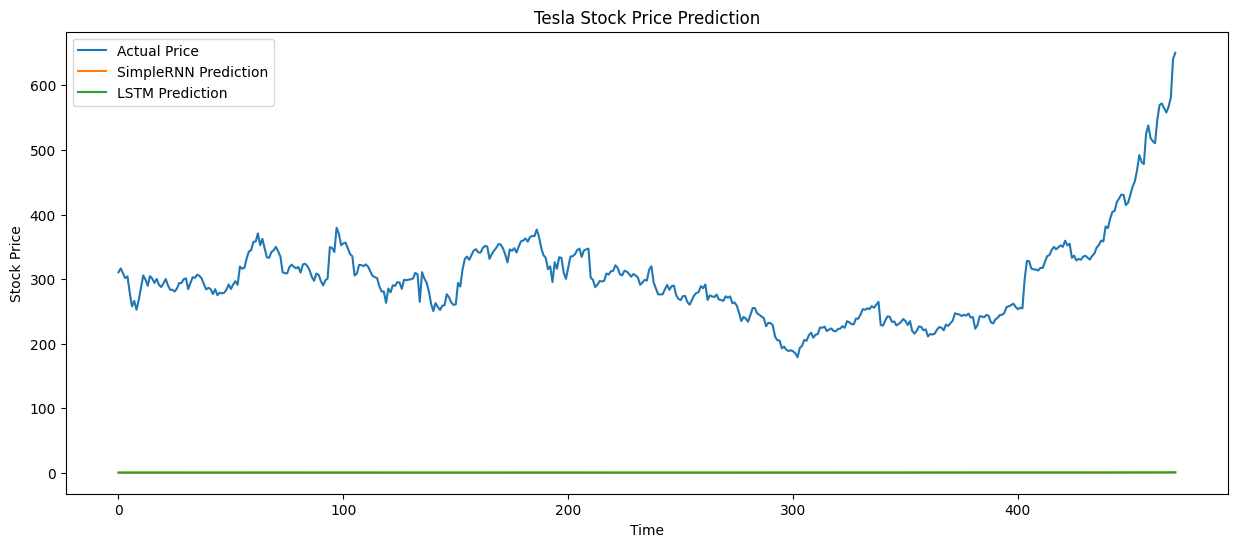

In [85]:
plt.figure(figsize=(15,6))
plt.plot(y1_test_actual, label='Actual Price')
plt.plot(rnn_predictions, label='SimpleRNN Prediction')
plt.plot(lstm_predictions, label='LSTM Prediction')
plt.title("Tesla Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

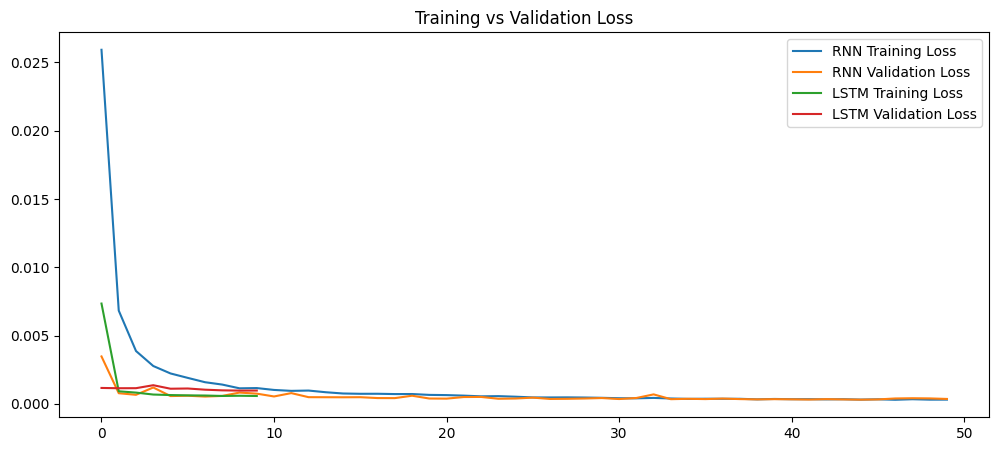

In [86]:
plt.figure(figsize=(12,5))
plt.plot(history_rnn.history['loss'], label='RNN Training Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [87]:
units_list = [32, 50]
dropout_list = [0.2, 0.3]
learning_rates = [0.001, 0.0001]

In [88]:
best_loss = np.inf
best_params = None

In [89]:
for units in units_list:
  for dropout in dropout_list:

      for lr in learning_rates:

          print(f"\nTraining with Units={units}, Dropout={dropout}, LR={lr}")

          temp_model = build_lstm_model(
              units=units,
              dropout_rate=dropout,
              learning_rate=lr
          )

          history = temp_model.fit(
              X1_train,
              y1_train,
              validation_data=(X1_test, y1_test),
              epochs=10,
              batch_size=32,
              verbose=0
          )

          val_loss = min(history.history['val_loss'])

          if val_loss < best_loss:

              best_loss = val_loss

              best_params = {
                  'Units': units,
                  'Dropout': dropout,
                 'Learning Rate': lr
             }


Training with Units=32, Dropout=0.2, LR=0.001

Training with Units=32, Dropout=0.2, LR=0.0001

Training with Units=32, Dropout=0.3, LR=0.001

Training with Units=32, Dropout=0.3, LR=0.0001

Training with Units=50, Dropout=0.2, LR=0.001

Training with Units=50, Dropout=0.2, LR=0.0001

Training with Units=50, Dropout=0.3, LR=0.001

Training with Units=50, Dropout=0.3, LR=0.0001


In [90]:
print("\nBest Parameters:")
print(best_params)

print("\nBest Validation Loss:")
print(best_loss)


Best Parameters:
{'Units': 50, 'Dropout': 0.3, 'Learning Rate': 0.001}

Best Validation Loss:
0.000957061885856092


In [91]:
lstm_5day = build_lstm_model()
lstm_5day.fit(
X5_train,
y5_train,
epochs=20,
batch_size=32,
validation_data=(X5_test, y5_test),
verbose=1
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0067 - val_loss: 0.0025
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5231e-04 - val_loss: 0.0020
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.7377e-04 - val_loss: 0.0024
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5520e-04 - val_loss: 0.0023
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.2937e-04 - val_loss: 0.0025
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.8207e-04 - val_loss: 0.0031
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.6815e-04 - val_loss: 0.0021
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.9111e-04 - val_loss: 0.0023
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.3066e-04 - val_loss: 0.0020
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.9837e-04 - val_loss: 0.0020
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.5644e-04 - val_loss: 0.0018
Epoch 12/20
59/59 ━━━━━

In [93]:
lstm_10day = build_lstm_model()

lstm_10day.fit(X10_train,y10_train,epochs=20,batch_size=32,validation_data=(X10_test, y10_test),verbose=1)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0066 - val_loss: 0.0038
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0010 - val_loss: 0.0032
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0010 - val_loss: 0.0033
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.6794e-04 - val_loss: 0.0039
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.4033e-04 - val_loss: 0.0038
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.2414e-04 - val_loss: 0.0033
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.1934e-04 - val_loss: 0.0033
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 8.4826e-04 - val_loss: 0.0032
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.3908e-04 - val_loss: 0.0031
Epoch 12/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 

In [95]:
from sklearn.metrics import mean_absolute_percentage_error

def calculate_accuracy(actual, predicted, model_name):

  # MAPE
  mape = mean_absolute_percentage_error(actual, predicted)

  # Accuracy %
  accuracy = (1 - mape) * 100

  print(f"\n{model_name} Accuracy")
  print("-"*40)
  print("MAPE :", round(mape, 4))
  print("Accuracy :", round(accuracy, 2), "%")

calculate_accuracy(
y1_test_actual,
rnn_predictions,
"SimpleRNN"
)


SimpleRNN Accuracy
----------------------------------------
MAPE : 0.9988
Accuracy : 0.12 %


In [96]:
calculate_accuracy(
y1_test_actual,
lstm_predictions,
"LSTM"
)


LSTM Accuracy
----------------------------------------
MAPE : 0.9987
Accuracy : 0.13 %
